In [35]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import resample_poly

acceleration: g
angular velocity: rad/s
x axis: vertical, positive up
y axis: antero-frontal, positive backwards
z axis: medio-lateral, positive right

### Common functions

In [36]:
def check_axes(df, subject_id=1, session_id=1, task_id=0):
    subset = df[
        (df['subjectID'] == subject_id) & 
        (df['sessionID'] == session_id) & 
        (df['taskID'] == task_id)
    ].copy()
    
    print(f"X orig: {subset['acc_x'].mean():+.3f} g")
    print(f"Y orig: {subset['acc_y'].mean():+.3f} g")
    print(f"Z orig: {subset['acc_z'].mean():+.3f} g")
    print(f"Var X: {subset['acc_x'].var():.5f}")
    print(f"Var Y: {subset['acc_y'].var():.5f}")
    print(f"Var Z: {subset['acc_z'].var():.5f}")

In [37]:
sensor_cols = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]
group_cols = ["subjectID", "sessionID", "taskID"]

In [38]:
def my_resample_poly(df_trial, up, down):
    subjectID, sessionID, taskID = df_trial.name
    x_orig = df_trial[sensor_cols].values

    x_resampled = resample_poly(x_orig, up=up, down=down, axis=0,padtype='line')

    t_orig = df_trial['timestamp'].values
    t0, t_end = t_orig[0], t_orig[-1]
    n_new_samples = x_resampled.shape[0]
    t_new = np.linspace(t0, t_end, n_new_samples)

    resampled_data = {'timestamp': t_new}
    for i, col in enumerate(sensor_cols):
        resampled_data[col] = x_resampled[:, i] 
        
    resampled_data[group_cols[0]] = subjectID
    resampled_data[group_cols[1]] = sessionID
    resampled_data[group_cols[2]] = taskID
        
    return pd.DataFrame(resampled_data)

## FoG-STAR

In [39]:
fog_star_sensor = pd.read_csv("data/FoG-STAR/sensor_data.csv")
fog_star_sensor= fog_star_sensor[fog_star_sensor.activity>0]
fog_star_sensor.columns

Index(['timestamp', 'ankleL_acc_x', 'ankleL_acc_y', 'ankleL_acc_z',
       'ankleL_gyro_x', 'ankleL_gyro_y', 'ankleL_gyro_z', 'ankleR_acc_x',
       'ankleR_acc_y', 'ankleR_acc_z', 'ankleR_gyro_x', 'ankleR_gyro_y',
       'ankleR_gyro_z', 'back_acc_x', 'back_acc_y', 'back_acc_z',
       'back_gyro_x', 'back_gyro_y', 'back_gyro_z', 'wrist_acc_x',
       'wrist_acc_y', 'wrist_acc_z', 'wrist_gyro_x', 'wrist_gyro_y',
       'wrist_gyro_z', 'activity', 'fog', 'fog_severity', 'subjectID',
       'sessionID', 'taskID'],
      dtype='str')

In [40]:
#keep only the columns that are needed for the analysis and rename them for better understanding
fog_star_sensor = fog_star_sensor[["timestamp", "back_acc_x", "back_acc_y", "back_acc_z", "back_gyro_x", "back_gyro_y", "back_gyro_z","subjectID", "sessionID", "activity", "fog"]]
fog_star_sensor.columns = ["timestamp", "acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z" ,"subjectID", "sessionID", "taskID", "fog"]

In [41]:
# keep only tasks 3 stance and 6,7 turn
# keep also task 4 sit to stand to verify axes
fog_star_sensor = fog_star_sensor[fog_star_sensor.taskID.isin([4, 3, 6, 7])]

# discard rows with taskId 6,7 and fog=1
fog_star_sensor = fog_star_sensor[~((fog_star_sensor.taskID.isin([6, 7])) & (fog_star_sensor.fog == 1))]

# map taskID to new code
task_mapping = {
    4:10,
    3: 0,
    6: 2,
    7: 2}
fog_star_sensor.taskID = fog_star_sensor.taskID.map(task_mapping)
fog_star_sensor.drop(columns=["fog"], inplace=True)
fog_star_sensor.describe()

,timestamp,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,subjectID,sessionID,taskID
count,112771.000000,106624.000000,106294.000000,106294.000000,106152.000000,106152.000000,106152.000000,112771.000000,112771.000000,112771.000000
mean,2667.445174,-0.954964,-0.080421,-0.154138,3.263188,0.488453,0.092058,10.186786,1.100283,1.856169
std,1454.085219,0.091881,0.162483,0.221046,39.537067,16.146598,12.199910,6.222944,0.361989,2.703174
min,8.100000,-1.944434,-1.180959,-1.736698,-208.647952,-666.976768,-162.603463,1.000000,1.000000,0.000000
25%,1482.125000,-1.003778,-0.183212,-0.323712,-6.135054,-3.560371,-3.126484,4.000000,1.000000,0.000000
50%,2583.383333,-0.964999,-0.062976,-0.137317,0.219056,0.146737,-0.359420,10.000000,1.000000,2.000000
75%,3918.825000,-0.907478,0.041231,0.000307,13.608803,4.287864,2.433344,16.000000,1.000000,2.000000
max,5483.600000,0.129237,0.905428,1.235253,239.919663,759.848404,268.316972,22.000000,3.000000,10.000000


In [42]:
fog_star_sensor = fog_star_sensor.sort_values(by=['subjectID', 'sessionID', 'timestamp']).reset_index(drop=True)
sensor_cols = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']
fog_star_sensor['is_nan'] = fog_star_sensor[sensor_cols].isna().any(axis=1)
fog_star_sensor['prev_is_nan'] = fog_star_sensor.groupby('subjectID')['is_nan'].shift(1, fill_value=True)
fog_star_sensor['time_diff'] = fog_star_sensor.groupby('subjectID')['timestamp'].diff()
fog_star_sensor['is_new_segment'] = (
    (~fog_star_sensor['is_nan']) &  
    (
        fog_star_sensor['prev_is_nan'] |  
        (fog_star_sensor['time_diff'] > 1.0) |  
        (fog_star_sensor['time_diff'].isna())   
    )
)

fog_star_sensor['new_sessionID'] = fog_star_sensor.groupby('subjectID')['is_new_segment'].cumsum()
fog_star_sensor = fog_star_sensor[~fog_star_sensor['is_nan']].copy()
fog_star_sensor['sessionID'] = fog_star_sensor['new_sessionID']
fog_star_sensor.drop(columns=['is_nan', 'prev_is_nan', 'time_diff', 'is_new_segment', 'new_sessionID'], inplace=True)
fog_star_sensor = fog_star_sensor.reset_index(drop=True) 

fog_star_sensor['timestamp'] = fog_star_sensor['timestamp'] - fog_star_sensor.groupby(['subjectID', 'sessionID'])['timestamp'].transform('min')

In [43]:
# from deg/s to rad/s
fog_star_sensor["gyro_x"] = np.deg2rad(fog_star_sensor["gyro_x"])
fog_star_sensor["gyro_y"] = np.deg2rad(fog_star_sensor["gyro_y"])
fog_star_sensor["gyro_z"] = np.deg2rad(fog_star_sensor["gyro_z"])

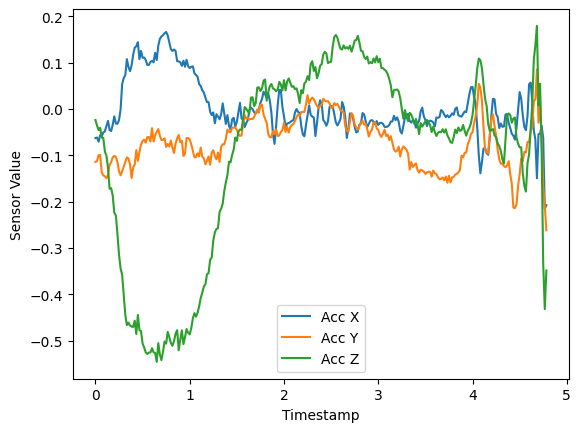

In [44]:
# plot the sensor data for one subject and session
subject_id = 1
session_id = 1
task_id = 10
subject_data = fog_star_sensor[(fog_star_sensor.subjectID == subject_id) & (fog_star_sensor.sessionID == session_id) & (fog_star_sensor.taskID == task_id) ]
subject_data["acc_x"] = subject_data["acc_x"] - subject_data["acc_x"].mean()
plt.plot(subject_data.timestamp, subject_data["acc_x"], label="Acc X")
plt.plot(subject_data.timestamp, subject_data["acc_y"], label="Acc Y")
plt.plot(subject_data.timestamp, subject_data["acc_z"], label="Acc Z")
plt.xlabel("Timestamp")
plt.ylabel("Sensor Value")
plt.legend()

In [45]:
check_axes(fog_star_sensor, subject_id=1, session_id=1, task_id=10)

X orig: -0.986 g
Y orig: -0.071 g
Z orig: -0.100 g
Var X: 0.00365
Var Y: 0.00293
Var Z: 0.04448


In [46]:
# exchange axes
cols_ordered = ['timestamp', 'subjectID', 'sessionID', 'taskID', 'acc_x', 'acc_z', 'acc_y', 'gyro_x', 'gyro_z', 'gyro_y']
fog_star_sensor = fog_star_sensor[cols_ordered]
fog_star_sensor.columns = ['timestamp', 'subjectID', 'sessionID', 'taskID', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

In [47]:
fog_star_resampled = (
    fog_star_sensor
    .groupby(group_cols, group_keys=False)
    .apply(my_resample_poly, up=16, down=15) 
    .reset_index(drop=True)
)

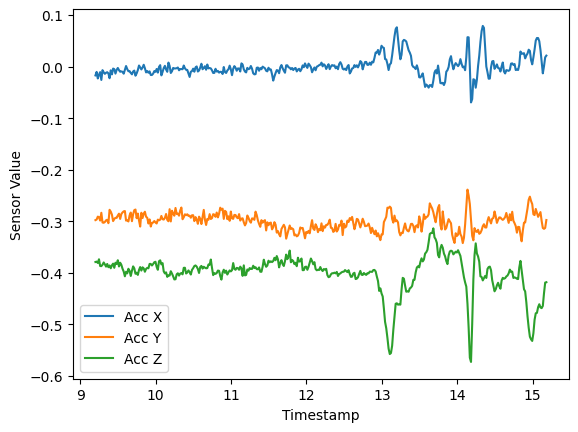

In [48]:
# plot the sensor data for one subject and session
subject_id = 2
session_id = 1
task_id = 0
subject_data = fog_star_resampled[(fog_star_resampled.subjectID == subject_id) & (fog_star_resampled.sessionID == session_id) & (fog_star_resampled.taskID == task_id) ]
subject_data["acc_x"] = subject_data["acc_x"] - subject_data["acc_x"].mean()
plt.plot(subject_data.timestamp, subject_data["acc_x"], label="Acc X")
plt.plot(subject_data.timestamp, subject_data["acc_y"], label="Acc Y")
plt.plot(subject_data.timestamp, subject_data["acc_z"], label="Acc Z")
plt.xlabel("Timestamp")
plt.ylabel("Sensor Value")
plt.legend()

In [49]:
# remove tug task from the dataset
fog_star_resampled = fog_star_resampled[fog_star_resampled.taskID != 10].copy()

In [50]:
fog_star_clinical = pd.read_csv("data/FoG-STAR/clinical_data.csv")
fog_star_clinical.head()

,subjectID,age,gender,disease_duration,h_y,updrs_iii,fog_q,moca,fes-i,pdq8
0,1,65,M,15.0,4.0,47,19,17.0,29.0,22
1,2,72,F,10.0,4.0,61,17,17.0,27.0,29
2,3,83,F,6.0,4.0,57,18,15.0,25.0,12
3,4,85,M,3.0,2.0,40,8,22.0,11.0,3
4,5,62,M,11.0,2.0,21,15,26.0,15.0,13


### OMNIA-PARK

In [51]:
folder_path = "data/OMNIA-PARK/pd"

all_data = []

for file in os.listdir(folder_path):
    if file.endswith('.csv'):
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path)
        df = df.rename(columns={"Hips_timestamp": "Timestamp"})
        
        df = df[["subjectID", "Timestamp", "Hips_accX", "Hips_accY", "Hips_accZ", "Hips_gyroX", "Hips_gyroY", "Hips_gyroZ", "taskID"]].copy()
        df.columns = ["subjectID", "timestamp", "acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z", "taskID"]

        df = df[df.taskID.isin([7, 8, 2,4])]
        task_mapping = {7: 0, 8: 1, 2: 2, 4: 10}
        df.taskID = df.taskID.map(task_mapping)
        df["sessionID"] = 1
        
        all_data.append(df)

omnia_park_sensor = pd.concat(all_data, ignore_index=True)

In [52]:
# from deg/s to rad/s
omnia_park_sensor["gyro_x"] = np.deg2rad(omnia_park_sensor["gyro_x"])
omnia_park_sensor["gyro_y"] = np.deg2rad(omnia_park_sensor["gyro_y"])
omnia_park_sensor["gyro_z"] = np.deg2rad(omnia_park_sensor["gyro_z"])

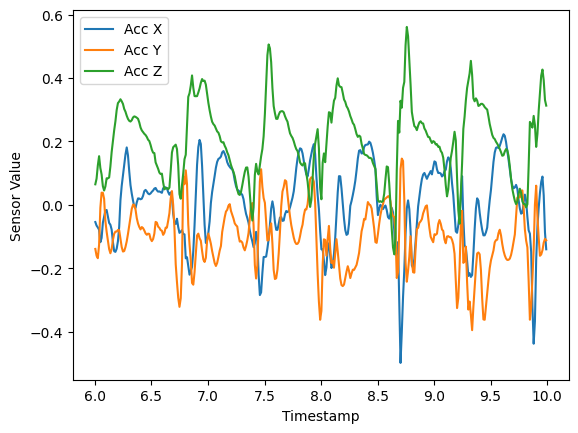

In [53]:
# plot the sensor data for one subject and session
subject_id = 1
session_id = 1
task_id = 2
subject_data = omnia_park_sensor[(omnia_park_sensor.subjectID == subject_id) & (omnia_park_sensor.sessionID == session_id) & (omnia_park_sensor.taskID == task_id) & (6 < omnia_park_sensor.timestamp) & (omnia_park_sensor.timestamp < 10)]
subject_data["acc_x"] = subject_data["acc_x"] - subject_data["acc_x"].mean()
plt.plot(subject_data.timestamp, subject_data["acc_x"], label="Acc X")
plt.plot(subject_data.timestamp, subject_data["acc_y"], label="Acc Y")
plt.plot(subject_data.timestamp, subject_data["acc_z"], label="Acc Z")
plt.xlabel("Timestamp")
plt.ylabel("Sensor Value")
plt.legend()

In [54]:
check_axes(omnia_park_sensor, subject_id=1, session_id=1, task_id=2)

X orig: -0.974 g
Y orig: -0.105 g
Z orig: +0.203 g
Var X: 0.01767
Var Y: 0.01078
Var Z: 0.01577


In [55]:
# exchange axes
cols_ordered = ['timestamp', 'subjectID', 'sessionID', 'taskID', 'acc_x', 'acc_z', 'acc_y', 'gyro_x', 'gyro_z', 'gyro_y']
omnia_park_sensor = omnia_park_sensor[cols_ordered]
omnia_park_sensor.columns = ['timestamp', 'subjectID', 'sessionID', 'taskID', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

In [56]:
time_diff = subject_data['timestamp'].diff().mean()
freq_hz = 1 / time_diff
print(f"Frequency: {freq_hz:.2f} Hz")

Frequency: 90.00 Hz


In [57]:
omnia_park_resampled = (
     omnia_park_sensor
    .groupby(group_cols, group_keys=False)
    .apply(my_resample_poly, up=32, down=45) 
    .reset_index(drop=True)
)

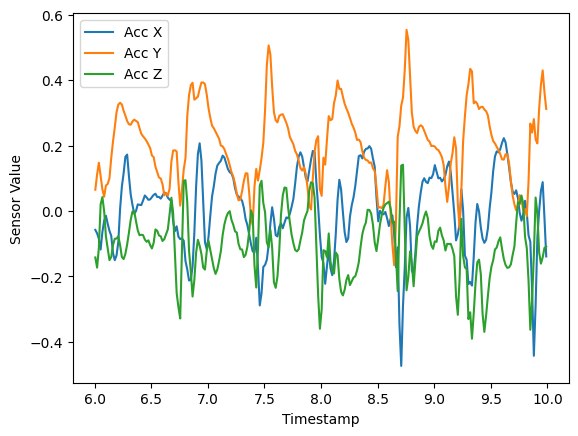

In [58]:
# plot the sensor data for one subject and session
subject_id = 1
session_id = 1
task_id = 2
subject_data = omnia_park_resampled[(omnia_park_resampled.subjectID == subject_id) & (omnia_park_resampled.sessionID == session_id) & (omnia_park_resampled.taskID == task_id) & (6 < omnia_park_resampled.timestamp) & (omnia_park_resampled.timestamp < 10)]
subject_data["acc_x"] = subject_data["acc_x"] - subject_data["acc_x"].mean()
plt.plot(subject_data.timestamp, subject_data["acc_x"], label="Acc X")
plt.plot(subject_data.timestamp, subject_data["acc_y"], label="Acc Y")
plt.plot(subject_data.timestamp, subject_data["acc_z"], label="Acc Z")
plt.xlabel("Timestamp")
plt.ylabel("Sensor Value")
plt.legend()

In [59]:
omnia_park_resampled = omnia_park_resampled[omnia_park_resampled.taskID != 10].copy()

In [60]:
omnia_park_clinical = pd.read_excel("data/OMNIA-PARK/clinical_info.xlsx")
omnia_park_clinical = omnia_park_clinical.rename(columns={"mds_updrs_3": "updrs_iii"})
omnia_park_clinical.head()

,subjectID,age,gender,disease_duration,h_y,updrs_iii,berg,postural_stability,posture,arising_chair
0,1,73,M,6,2.5,22,51,1,2,0
1,2,76,M,11,3.0,35,50,0,2,1
2,3,62,F,4,2.5,20,49,1,2,0
3,4,77,M,10,3.0,54,50,3,2,0
4,5,71,M,21,3.0,28,50,0,2,0


## PD-PHONE
x: verticale
y: medio-laterale
z: antero-posteriore

In [61]:
folder_path = "data/PD-PHONE/pd"

all_data = []

for file in os.listdir(folder_path):
    if file.endswith('.csv'):
        file_path = os.path.join(folder_path, file)
        subject_id = file.split('.')[0].split('_')[1].replace('pd', '')  
        
        df = pd.read_csv(file_path)
        
        df = df.iloc[:, [0, 1, 2, 3, 4, 5, -1]].copy()
        df.columns = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z", "taskID"]
        
        df = df[df.taskID == 3].copy()
        
        df["taskID"] = 0
        
        df["subjectID"] = int(subject_id)
        df["sessionID"] = 1
        
        df["timestamp"] = np.arange(len(df)) / 200.0
        all_data.append(df)

pd_phone_sensor = pd.concat(all_data, ignore_index=True)
pd_phone_sensor.columns

Index(['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'taskID',
       'subjectID', 'sessionID', 'timestamp'],
      dtype='str')

In [62]:
g = 9.80665
pd_phone_sensor["acc_x"] = pd_phone_sensor["acc_x"] / g
pd_phone_sensor["acc_y"] = pd_phone_sensor["acc_y"] / g
pd_phone_sensor["acc_z"] = pd_phone_sensor["acc_z"] / g

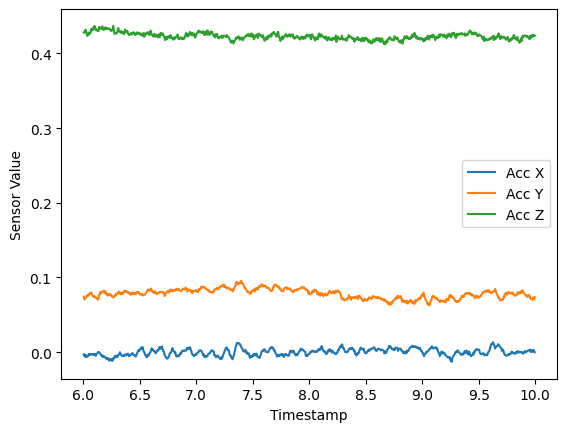

In [63]:
# plot the sensor data for one subject and session
subject_id = 1
session_id = 1
task_id = 0
subject_data = pd_phone_sensor[(pd_phone_sensor.subjectID == subject_id) & (pd_phone_sensor.sessionID == session_id) & (pd_phone_sensor.taskID == task_id) & (6 < pd_phone_sensor.timestamp) & (pd_phone_sensor.timestamp < 10)]
subject_data["acc_x"] = subject_data["acc_x"] - subject_data["acc_x"].mean()
plt.plot(subject_data.timestamp, subject_data["acc_x"], label="Acc X")
plt.plot(subject_data.timestamp, subject_data["acc_y"], label="Acc Y")
plt.plot(subject_data.timestamp, subject_data["acc_z"], label="Acc Z")
plt.xlabel("Timestamp")
plt.ylabel("Sensor Value")
plt.legend()

In [64]:
check_axes(pd_phone_sensor, subject_id=1, session_id=1, task_id=0)

X orig: +0.884 g
Y orig: +0.075 g
Z orig: +0.415 g
Var X: 0.00005
Var Y: 0.00005
Var Z: 0.00012


In [65]:
pd_phone_sensor['acc_x'] = -pd_phone_sensor['acc_x']
pd_phone_sensor['gyro_x'] = -pd_phone_sensor['gyro_x']
pd_phone_sensor[['acc_y', 'acc_z']] = pd_phone_sensor[['acc_z', 'acc_y']]
pd_phone_sensor[['gyro_y', 'gyro_z']] = pd_phone_sensor[['gyro_z', 'gyro_y']]

In [66]:
pd_phone_resampled = (
     pd_phone_sensor
    .groupby(group_cols, group_keys=False)
    .apply(my_resample_poly, up=8, down=25) 
    .reset_index(drop=True)
)

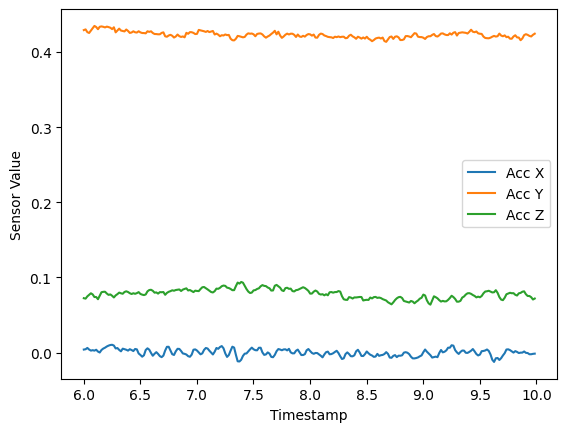

In [67]:
# plot the sensor data for one subject and session
subject_id = 1
session_id = 1
task_id = 0
subject_data = pd_phone_resampled[(pd_phone_resampled.subjectID == subject_id) & (pd_phone_resampled.sessionID == session_id) & (pd_phone_resampled.taskID == task_id) & (6 < pd_phone_resampled.timestamp) & (pd_phone_resampled.timestamp < 10)]
subject_data["acc_x"] = subject_data["acc_x"] - subject_data["acc_x"].mean()
plt.plot(subject_data.timestamp, subject_data["acc_x"], label="Acc X")
plt.plot(subject_data.timestamp, subject_data["acc_y"], label="Acc Y")
plt.plot(subject_data.timestamp, subject_data["acc_z"], label="Acc Z")
plt.xlabel("Timestamp")
plt.ylabel("Sensor Value")
plt.legend()

In [68]:
pd_phone_clinical = pd.read_excel("data/PD-PHONE/clinical_info.xlsx")
pd_phone_clinical.head()

,subjectID,age,gender,disease_duration,h_y,updrs_iii,postural_stability,posture,dyskinesia,other_info
0,1,55.0,M,4.0,NaN,NaN,1.0,1.0,no,prima visita
1,2,84.0,M,3.0,NaN,NaN,NaN,NaN,no,"Encefalomielite, PT negativo ma molto instabile"
2,3,79.0,M,20.0,3.0,35.0,2.0,2.0,no,DBS
3,4,76.0,M,13.0,NaN,25.0,1.0,1.0,no,NaN
4,5,75.0,M,13.0,NaN,NaN,0.0,2.0,no,NaN


### WearPD

In [69]:
folder_path = "data/WearPD/pd"
all_data = []

col_keep = [
    'Time', 'GeneralEvent', 'ClinicalEvent',
    'LowerBack_Acc_X', 'LowerBack_Acc_Y', 'LowerBack_Acc_Z',
    'LowerBack_Gyr_X', 'LowerBack_Gyr_Y', 'LowerBack_Gyr_Z'
]

col_map = {
    'Time': 'timestamp',
    'LowerBack_Acc_X': 'acc_x', 'LowerBack_Acc_Y': 'acc_y', 'LowerBack_Acc_Z': 'acc_z',
    'LowerBack_Gyr_X': 'gyro_x', 'LowerBack_Gyr_Y': 'gyro_y', 'LowerBack_Gyr_Z': 'gyro_z'
}

for file in os.listdir(folder_path):
    if file.endswith('balance.csv') or file.endswith('selfpace_matturn.csv') or file.endswith('tug.csv'):
        file_path = os.path.join(folder_path, file)
        
        subject_id = file.split('_')[0]
        try:
            df = pd.read_csv(file_path, usecols=col_keep)
        except ValueError:
            print(f"Missing LowerBack sensor in: {file}. File skipped.")
            continue
        
    
        df_parts = [] 
        
        if 'balance' in file:
            df0 = df[df['GeneralEvent'].str.contains('EO_FeetShoWidth', na=False)].copy()
            df0['taskID'] = 0
            df_parts.append(df0)
                
            # Task 1: closed eyes, feet apart
            df1 = df[df['GeneralEvent'].str.contains('EC_FeetShoWidth', na=False)].copy()
            df1['taskID'] = 1
            df_parts.append(df1)
                
        elif 'selfpace_mat' in file:
            # Task 2: Walk
            df2 = df[df['GeneralEvent'].str.contains('Turn', na=False)].copy()
            df2['taskID'] = 2
            df_parts.append(df2)
        
        elif "tug" in file:
            # Task 10: TUG
            df2 = df.copy()
            df2['taskID'] = 10
            df_parts.append(df2)
        
        if len(df_parts) > 0:
            df_file_completo = pd.concat(df_parts, ignore_index=True)
            df_file_completo = df_file_completo.rename(columns=col_map)
            df_file_completo["subjectID"] = subject_id
            df_file_completo["sessionID"] = 1
            df_file_completo.drop(columns=['GeneralEvent', 'ClinicalEvent'], inplace=True)
            df_file_completo["timestamp"] = df_file_completo["timestamp"].apply(lambda x: float(x.split(" ")[0]))
            
            all_data.append(df_file_completo)

wearpd_sensor = pd.concat(all_data, ignore_index=True)

Missing LowerBack sensor in: nls194_balance.csv. File skipped.
Missing LowerBack sensor in: nls194_selfpace_matturn.csv. File skipped.
Missing LowerBack sensor in: nls194_tug.csv. File skipped.


In [70]:
wearpd_sensor = wearpd_sensor.sort_values(by=['subjectID', 'taskID', 'timestamp']).reset_index(drop=True)

sensor_cols = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

wearpd_sensor['time_diff'] = wearpd_sensor.groupby(['subjectID', 'taskID'])['timestamp'].diff()
wearpd_sensor['is_nan'] = wearpd_sensor[sensor_cols].isna().any(axis=1)

wearpd_sensor['is_new_segment'] = (
    (wearpd_sensor['time_diff'] > 0.5) | 
    (wearpd_sensor['time_diff'].isna()) | 
    (wearpd_sensor[sensor_cols].shift(1).isna().any(axis=1) & ~wearpd_sensor['is_nan'])
)

wearpd_sensor['sessionID'] = wearpd_sensor.groupby(['subjectID', 'taskID'])['is_new_segment'].cumsum()


wearpd_sensor = wearpd_sensor.dropna(subset=sensor_cols).copy()

wearpd_sensor['timestamp'] = wearpd_sensor['timestamp'] - wearpd_sensor.groupby(['subjectID', 'taskID', 'sessionID'])['timestamp'].transform('min')


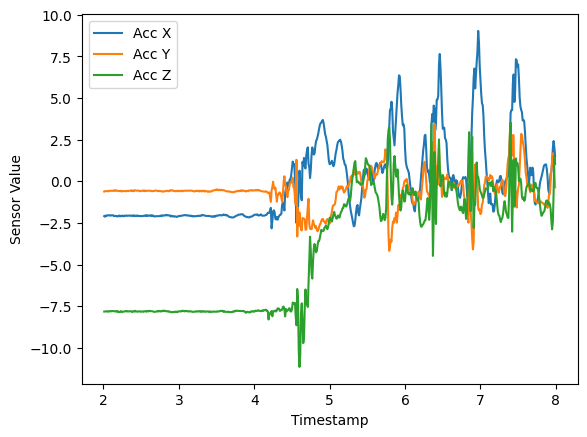

In [71]:
# plot the sensor data for one subject and session
subject_id = "nls002"
session_id = 1
task_id = 10
subject_data = wearpd_sensor[(wearpd_sensor.subjectID == subject_id) & (wearpd_sensor.sessionID == session_id) & (wearpd_sensor.taskID == task_id) & (2 < wearpd_sensor.timestamp) & (wearpd_sensor.timestamp < 8)]
subject_data["acc_x"] = subject_data["acc_x"] - subject_data["acc_x"].mean()
plt.plot(subject_data.timestamp, subject_data["acc_x"], label="Acc X")
plt.plot(subject_data.timestamp, subject_data["acc_y"], label="Acc Y")
plt.plot(subject_data.timestamp, subject_data["acc_z"], label="Acc Z")
plt.xlabel("Timestamp")
plt.ylabel("Sensor Value")
plt.legend()

In [72]:
time_diff = subject_data['timestamp'].diff().mean()
freq_hz = 1 / time_diff
print(f"Frequency: {freq_hz:.2f} Hz")

Frequency: 100.00 Hz


In [73]:
wearpd_sensor["acc_x"] = wearpd_sensor["acc_x"] / g
wearpd_sensor["acc_y"] = wearpd_sensor["acc_y"] / g
wearpd_sensor["acc_z"] = wearpd_sensor["acc_z"] / g

In [74]:
check_axes(wearpd_sensor, subject_id="nls002", session_id=1, task_id=10)

X orig: +0.880 g
Y orig: -0.055 g
Z orig: -0.338 g
Var X: 0.04459
Var Y: 0.01406
Var Z: 0.10993


In [75]:
wearpd_resampled = (
    wearpd_sensor
    .groupby(group_cols, group_keys=False)
    .apply(my_resample_poly, up=16, down=25) 
    .reset_index(drop=True)
)

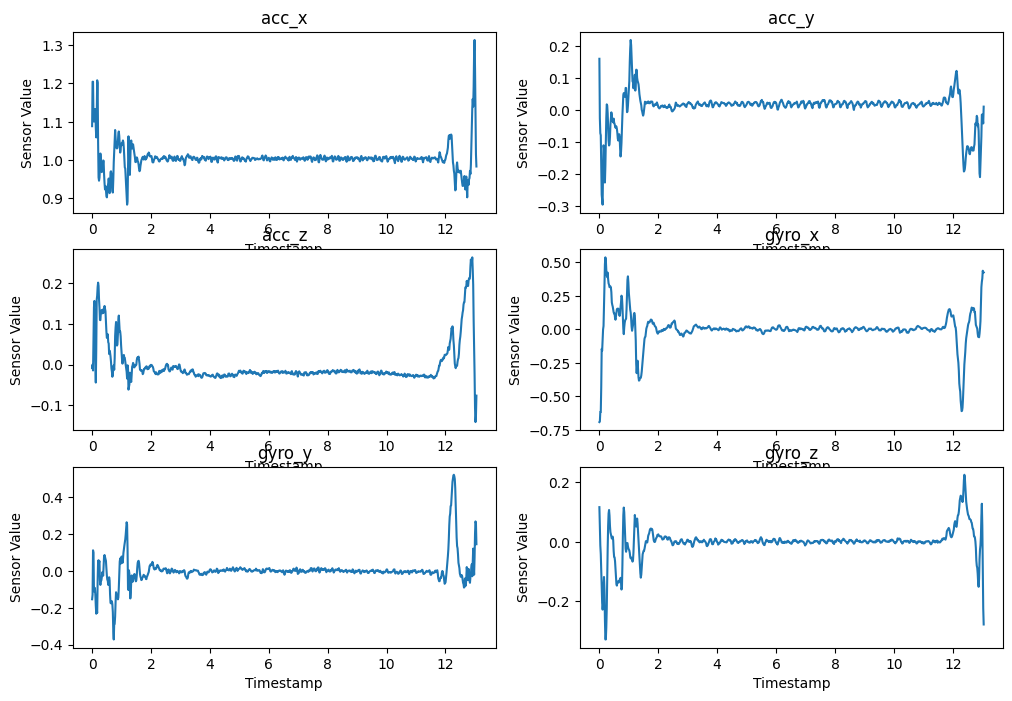

In [76]:
# plot the sensor data for one subject and session
subject_id = "nls002"
session_id = 1
task_id = 0
subject_data = wearpd_resampled[(wearpd_resampled.subjectID == subject_id) & (wearpd_resampled.sessionID == session_id) & (wearpd_resampled.taskID == task_id)]
plt.figure(figsize=(12, 8))
for i, col in enumerate(sensor_cols):
    plt.subplot(3, 2, i+1)
    plt.plot(subject_data.timestamp, subject_data[col])
    plt.title(col)
    plt.xlabel("Timestamp")
    plt.ylabel("Sensor Value")

In [77]:
wearpd_resampled = wearpd_resampled[wearpd_resampled.taskID != 10].copy()

In [78]:
wearpd_clinical = pd.read_csv("data/WearPD/PD - Demographic+Clinical - datasetV1.csv",header=[0, 1])
wearpd_clinical.columns

cols = []
for level1, level2 in wearpd_clinical.columns:
    l1 = str(level1).strip()
    l2 = str(level2).strip()
    if "Unnamed" in l1 or l1 == "-":
        cols.append(l2)
    else:
        cols.append(f"{l1}_{l2}")

wearpd_clinical.columns = cols

df_pd = wearpd_clinical.dropna(subset=['Subject ID']).copy()
df_pd['Subject ID'] = df_pd['Subject ID'].apply(lambda x: str(x).lower())

updrs3_cols = [col for col in df_pd.columns if 'MDSUPDRS_3' in col]
for col in updrs3_cols:
    df_pd[col] = pd.to_numeric(df_pd[col], errors='coerce')
df_pd['updrs_iii'] = df_pd[updrs3_cols].sum(axis=1, skipna=True)

cols_to_keep = {
    'Subject ID': 'subjectID',
    'Age (years)': 'age',
    'Sex': 'gender',                    
    'Years since PD diagnosis': 'disease_duration',
    'Modified Hoehn & Yahr Score': 'h_y',
    'updrs_iii': 'updrs_iii',        
    'POSTURAL STABILITY_MDSUPDRS_3-12': 'postural_stability'
}

wearpd_clinical = df_pd[list(cols_to_keep.keys())].rename(columns=cols_to_keep)
mapping = { "Male" : "M", "Female" : "F" }
wearpd_clinical['gender'] = wearpd_clinical['gender'].map(mapping)
wearpd_clinical.head()


,subjectID,age,gender,disease_duration,h_y,updrs_iii,postural_stability
0,nls139,67,M,2.26,2,33.0,0.0
1,nls140,75,M,10.29,3,40.0,2.0
2,nls056,64,F,3.5,2,32.0,3.0
3,nls124,59,M,26.42,3,41.0,3.0
4,nls035,55,F,7.38,1,20.0,0.0


### Ensure datasets consistency

In [79]:
# for each dataset check if all users have a corresponding clinical record
datasets = ["fog_star", "omnia_park", "pd_phone", "wearpd"]
for dataset in datasets:
    print(f"Dataset: {dataset}")
    if dataset == "fog_star":
        sensor_df = fog_star_sensor
        clinical_df = fog_star_clinical
        subject_col = "subjectID"
    elif dataset == "omnia_park":
        sensor_df = omnia_park_sensor
        clinical_df = omnia_park_clinical
        subject_col = "subjectID"
    elif dataset == "pd_phone":
        sensor_df = pd_phone_sensor
        clinical_df = pd_phone_clinical
        subject_col = "subjectID"
    elif dataset == "wearpd":
        sensor_df = wearpd_sensor
        clinical_df = wearpd_clinical
        subject_col = "subjectID"
    
    sensor_subjects = set(sensor_df[subject_col].unique())
    clinical_subjects = set(clinical_df[subject_col].unique())
    
    missing_in_clinical = sensor_subjects - clinical_subjects
    missing_in_sensor = clinical_subjects - sensor_subjects
    
    if len(missing_in_clinical) > 0:
        print(f"  Subjects in sensor data but missing in clinical data: {missing_in_clinical}")
    else:
        print("  All subjects in sensor data have a corresponding clinical record.")
    
    if len(missing_in_sensor) > 0:
        print(f"  Subjects in clinical data but missing in sensor data: {missing_in_sensor}")
    else:
        print("  All subjects in clinical data have a corresponding sensor record.")


Dataset: fog_star
  All subjects in sensor data have a corresponding clinical record.
  All subjects in clinical data have a corresponding sensor record.
Dataset: omnia_park
  All subjects in sensor data have a corresponding clinical record.
  All subjects in clinical data have a corresponding sensor record.
Dataset: pd_phone
  All subjects in sensor data have a corresponding clinical record.
  All subjects in clinical data have a corresponding sensor record.
Dataset: wearpd
  All subjects in sensor data have a corresponding clinical record.
  Subjects in clinical data but missing in sensor data: {'nls194'}


In [80]:
# check columns correspondence between datasets and create final csv files for each dataset with only the columns needed for the analysis and renamed for better understanding
# create folder cleaned_data with the following structure:
# nameDataset_sensor.csv: subjectID, sessionID, taskID, timestamp, acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z
# nameDataset_clinical.csv: subjectID, age, gender, disease_duration, h_y, updrs_iii, postural_stability (Nan if not available)

output_folder = "cleaned_data"
os.makedirs(output_folder, exist_ok=True)

TARGET_SENSOR_COLS = [
    'subjectID', 'sessionID', 'taskID', 'timestamp', 
    'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z'
]

TARGET_CLINICAL_COLS = [
    'subjectID', 'age', 'gender', 'disease_duration', 
    'h_y', 'updrs_iii', 'postural_stability'
]

def save_dataset(df_sensor, df_clinical, dataset_name):
    df_s = df_sensor.copy()
    
    for col in TARGET_SENSOR_COLS:
        if col not in df_s.columns:
            df_s[col] = np.nan
            
    df_s = df_s[TARGET_SENSOR_COLS]
    df_s.to_csv(os.path.join(output_folder, f"{dataset_name}_sensor.csv"), index=False)

    if df_clinical is not None:
        df_c = df_clinical.copy()
        
        for col in TARGET_CLINICAL_COLS:
            if col not in df_c.columns:
                df_c[col] = np.nan
                
        df_c = df_c[TARGET_CLINICAL_COLS]
        df_c.to_csv(os.path.join(output_folder, f"{dataset_name}_clinical.csv"), index=False)


In [81]:
datasets_dict = {
    "fog_star": (fog_star_resampled, fog_star_clinical),
    "omnia_park": (omnia_park_resampled, omnia_park_clinical),
    "pd_phone": (pd_phone_resampled, pd_phone_clinical),
    "wearpd": (wearpd_resampled, wearpd_clinical)
}

for dataset_name, (df_sensor, df_clinical) in datasets_dict.items():
    print(f"\nProcessing dataset: {dataset_name}")
    
    if not df_sensor.empty:
        test_subject = df_sensor['subjectID'].iloc[0]
        test_session = df_sensor['sessionID'].iloc[0]
        test_task = df_sensor['taskID'].iloc[0]
        
        subject_data = df_sensor[(df_sensor['subjectID'] == test_subject) & (df_sensor['sessionID'] == test_session) & (df_sensor['taskID'] == test_task)]
        
        time_diff = subject_data['timestamp'].diff().mean()

        freq_hz = 1 / time_diff
        print(f"  Estimated frequency: {freq_hz:.2f} Hz")
        
    save_dataset(df_sensor, df_clinical, dataset_name)


Processing dataset: fog_star
  Estimated frequency: 64.12 Hz

Processing dataset: omnia_park
  Estimated frequency: 64.01 Hz

Processing dataset: pd_phone
  Estimated frequency: 63.99 Hz

Processing dataset: wearpd
  Estimated frequency: 63.98 Hz
